Assignment 9 — Decision Trees & Random Forests

Titanic & Heart Disease Classification

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Load dataset
data = load_breast_cancer()   # Heart disease alternative
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.shape)
print(np.unique(y))

(569, 30)
[0 1]


In [3]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Train models
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred1 = dt.predict(X_test)
pred2 = rf.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, pred1))
print("Random Forest:", accuracy_score(y_test, pred2))

Decision Tree: 0.9473684210526315
Random Forest: 0.9649122807017544


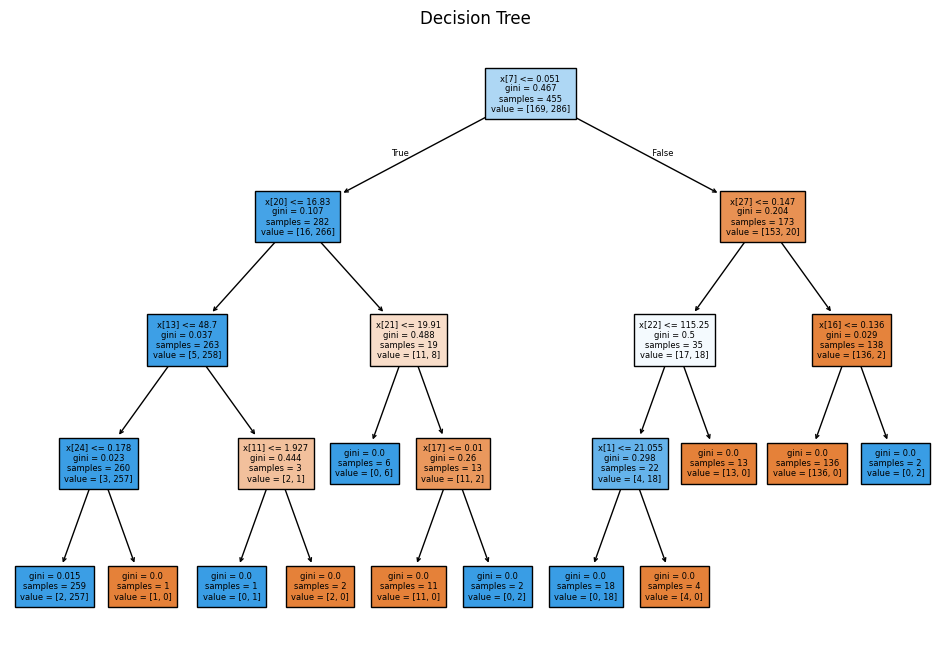

In [5]:
# Decision tree graph
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, fontsize=6)
plt.title("Decision Tree")
plt.show()

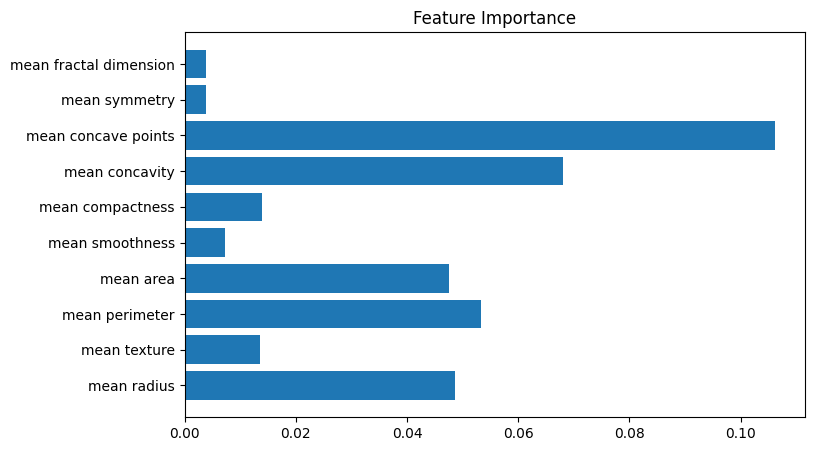

In [6]:
# Feature importance
imp = rf.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(X.columns[:10], imp[:10])
plt.title("Feature Importance")
plt.show()

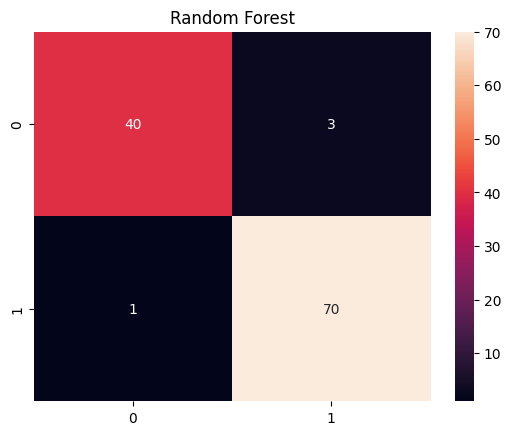

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, pred2)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest")
plt.show()

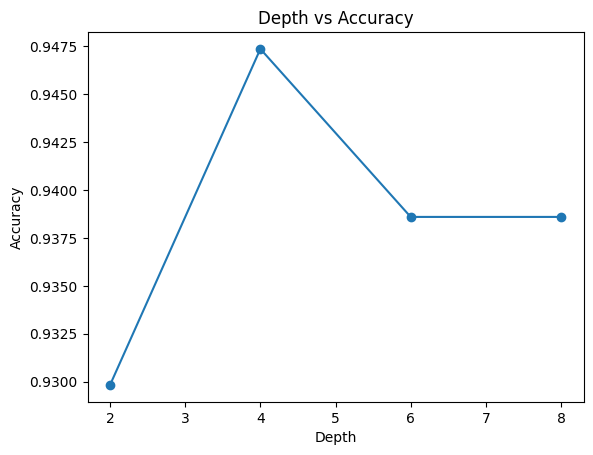

In [8]:
# Compare depth values
depth = [2,4,6,8]
acc = []

for d in depth:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, pred))

plt.plot(depth, acc, marker="o")
plt.title("Depth vs Accuracy")
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.show()

Conclusion:Decision Tree and Random Forest models were applied for classification. Random Forest gave better accuracy than Decision Tree. Tree depth affects performance, and feature importance shows important variables. Hence, Random Forest is more accurate and reliable.